In [ ]:
# Install required libs (run once in Colab)
!pip install xgboost shap lightgbm --quiet

In [ ]:
import os, pandas as pd, numpy as np
print("Files in /content:", os.listdir("/content"))

df = pd.read_csv("/content/Dataset_Ads.csv")
print("Shape:", df.shape)
display(df.head())
df.info()

Files in /content: ['.config', 'Dataset_Ads.csv', 'sample_data']
Shape: (10000, 11)


,Age,Gender,Income,Location,Ad Type,Ad Topic,Ad Placement,Clicks,Click Time,Conversion Rate,CTR
0,61,Male,35717.43,Urban,Banner,Travel,Social Media,3,2024-01-18 20:45:56.898459,0.0981,0.0737
1,41,Male,47453.25,Rural,Video,Travel,Search Engine,5,2023-04-24 20:45:56.898459,0.0937,0.0592
2,49,Female,68126.35,Rural,Text,Food,Social Media,4,2024-02-24 20:45:56.898459,0.1912,0.0563
3,68,Female,64585.73,Suburban,Text,Health,Website,6,2023-12-13 20:45:56.898459,0.1122,0.0232
4,63,Male,21109.40,Urban,Native,Fashion,Search Engine,5,2023-07-02 20:45:56.898459,0.1426,0.0539


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              10000 non-null  int64  
 1   Gender           10000 non-null  object 
 2   Income           10000 non-null  float64
 3   Location         10000 non-null  object 
 4   Ad Type          10000 non-null  object 
 5   Ad Topic         10000 non-null  object 
 6   Ad Placement     10000 non-null  object 
 7   Clicks           10000 non-null  int64  
 8   Click Time       10000 non-null  object 
 9   Conversion Rate  10000 non-null  float64
 10  CTR              10000 non-null  float64
dtypes: float64(3), int64(2), object(6)
memory usage: 859.5+ KB


In [ ]:
# Auto-detect target preference order
candidates = [c.lower() for c in df.columns]
target = None
target_type = None  # 'regression' or 'classification'

# Prefer CTR-like columns
for t in ['ctr', 'click_through_rate', 'clickrate', 'click_rate']:
    if t in candidates:
        target = df.columns[candidates.index(t)]
        target_type = 'regression'
        break

# Fallback: if clicks & impressions exist -> derive CTR
if target is None:
    if 'clicks' in candidates and 'impressions' in candidates:
        clicks_col = df.columns[candidates.index('clicks')]
        imp_col = df.columns[candidates.index('impressions')]
        df['CTR_derived'] = df[clicks_col] / (df[imp_col].replace({0:np.nan}))
        df['CTR_derived'] = df['CTR_derived'].fillna(0)
        target = 'CTR_derived'
        target_type = 'regression'

# Another fallback: binary click column for classification
if target is None:
    for t in ['click', 'clicked', 'is_click', 'is_clicked']:
        if t in candidates:
            target = df.columns[candidates.index(t)]
            target_type = 'classification'
            break

# Final fallback: use impressions or conversions if present (regression)
if target is None:
    for t in ['conversions', 'conversion', 'revenue', 'cpc']:
        if t in candidates:
            target = df.columns[candidates.index(t)]
            target_type = 'regression'
            break

if target is None:
    raise ValueError("Could not auto-detect a reasonable target column. "
                     "Please tell me which column should be predicted (CTR/Clicks/Conversions/CPC).")

print("Selected target:", target, "| type:", target_type)


Selected target: CTR | type: regression


In [ ]:
# Copy original for safety
data = df.copy()

# Drop columns with >80% missing or unique-id like columns
thresh = 0.8 * len(data)
drop_cols = [c for c in data.columns if data[c].isna().sum() > thresh]
# drop obvious id/time columns if present (you can edit)
for c in ['id', 'ad_id', 'campaign_id', 'timestamp', 'date']:
    if c in data.columns:
        drop_cols.append(c)
drop_cols = list(set(drop_cols))
print("Dropping columns:", drop_cols)
data = data.drop(columns=drop_cols, errors='ignore')

# Fill missing values
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = data[col].fillna('missing')
    else:
        data[col] = data[col].fillna(data[col].median())

# Simple feature: hour/day if timestamp exists (optional)
if 'datetime' in [c.lower() for c in data.columns]:
    # try to find datetime column and extract
    dt_col = [c for c in data.columns if c.lower()=='datetime'][0]
    try:
        data[dt_col] = pd.to_datetime(data[dt_col])
        data['hour'] = data[dt_col].dt.hour
        data['day'] = data[dt_col].dt.dayofweek
    except:
        pass

# Encode categorical columns with LabelEncoder (safe for tree models)
from sklearn.preprocessing import LabelEncoder
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)
le = LabelEncoder()
for col in cat_cols:
    try:
        data[col] = le.fit_transform(data[col].astype(str))
    except Exception as e:
        print("Encoding error", col, e)

# Final check
print("Prepared data shape:", data.shape)

Dropping columns: []
Categorical columns: ['Gender', 'Location', 'Ad Type', 'Ad Topic', 'Ad Placement', 'Click Time']
Prepared data shape: (10000, 11)


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=[target])
y = data[target]

# If classification but values not binary, convert to binary (presence/absence)
if target_type == 'classification':
    # convert to 0/1 if not already
    y = (y > 0).astype(int)

# Use an 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 10) (2000, 10) (8000,) (2000,)


In [ ]:
# Regression: XGBoost
if target_type == 'regression':
    from xgboost import XGBRegressor
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

# Classification: RandomForest
else:
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score

pred = model.predict(X_test)

if target_type == 'regression':
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"Regression results -> RMSE: {rmse:.6f} | R2: {r2:.4f}")
else:
    # some classifiers give probability arrays
    if hasattr(model, "predict_proba"):
        pred_proba = model.predict_proba(X_test)[:,1]
    else:
        pred_proba = None
    acc = accuracy_score(y_test, pred.round().astype(int))
    f1 = f1_score(y_test, pred.round().astype(int))
    print(f"Classification results -> Accuracy: {acc:.4f} | F1: {f1:.4f}")
    if pred_proba is not None:
        try:
            auc = roc_auc_score(y_test, pred_proba)
            print("ROC AUC:", auc)
        except:
            pass

Regression results -> RMSE: 0.020214 | R2: -0.0524


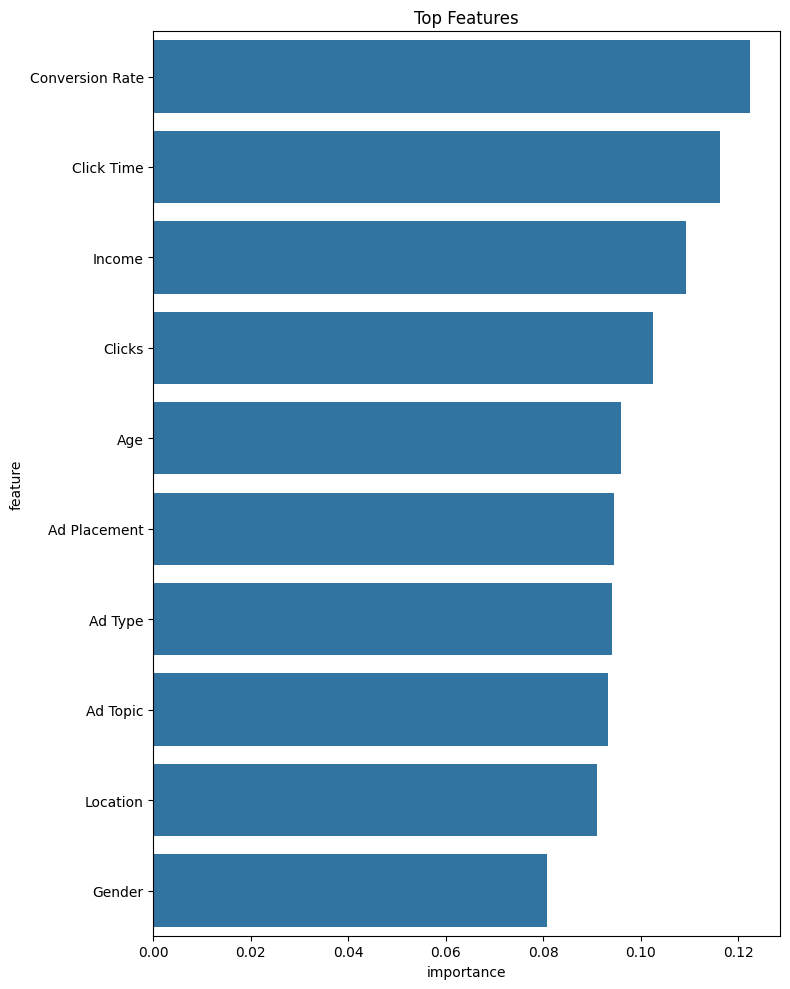

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Try model feature_importances_ first
if hasattr(model, 'feature_importances_'):
    fi = model.feature_importances_
    feat = X.columns
    imp_df = pd.DataFrame({'feature': feat, 'importance': fi}).sort_values('importance', ascending=False).head(30)
    plt.figure(figsize=(8,10))
    sns.barplot(x='importance', y='feature', data=imp_df)
    plt.title("Top Features")
    plt.tight_layout()
    plt.show()
else:
    print("Model does not expose feature_importances_")

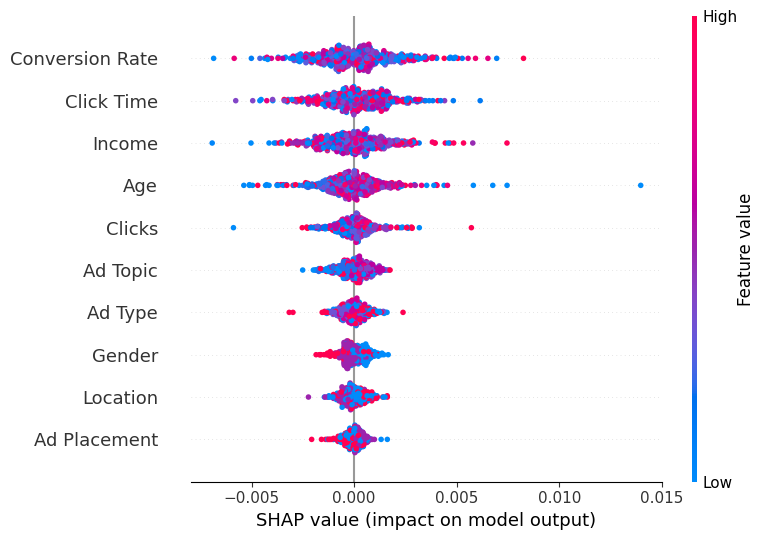

In [ ]:
import shap
# Use a small sample for SHAP to speed up
sample = X_test.sample(n=min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)  # works for tree models
shap_values = explainer.shap_values(sample)

# Summary plot
shap.summary_plot(shap_values, sample)

In [ ]:
import joblib
joblib.dump(model, "/content/ads_model.joblib")
print("Saved model to /content/ads_model.joblib")

Saved model to /content/ads_model.joblib
